# Cluster Threshold Sensitivity Analysis

Demonstrates `cluster_threshold_sensitivity()` — tests how different cluster
thresholds affect backtesting pass rates and cluster detection.

In [1]:
import numpy as np
import pandas as pd
from risk_backtest import (
    cluster_threshold_sensitivity,
    BacktestConfig,
    detect_cluster,
    run_backtest,
)

## Generate Data with Clustered Breaches

In [2]:
rng = np.random.default_rng(42)
n = 600

# Create 10 funds with different breach patterns
returns_dict = {}
var_dict = {}

for i in range(10):
    r = rng.normal(0, 0.01, n)
    v = np.full(n, 0.02)
    
    # Inject clusters of varying tightness
    cluster_start = 100 + i * 30
    gap = i + 1  # gap between breaches increases per fund
    for j in range(5):
        idx = cluster_start + j * gap
        if idx < n:
            r[idx] = -0.03
    
    returns_dict[f"Fund_{i:02d}"] = r
    var_dict[f"Fund_{i:02d}"] = v

print(f"Created {len(returns_dict)} funds with varying breach cluster tightness")

Created 10 funds with varying breach cluster tightness


## Run Sensitivity Analysis (verbose)

In [3]:
# Test thresholds 1 through 15
sensitivity_df = cluster_threshold_sensitivity(
    returns=returns_dict,
    risk_series=var_dict,
    thresholds=range(1, 16),
    window_sizes=[252, 504],
    n_jobs=-1,
    verbose=True,
)

[1/15] Cluster Threshold = 1  →  clusters=0.55, isolated=10.95, Kupiec pass=20.0%, Joint pass=32.5%
[2/15] Cluster Threshold = 2  →  clusters=0.95, isolated=9.95, Kupiec pass=22.5%, Joint pass=35.0%
[3/15] Cluster Threshold = 3  →  clusters=1.20, isolated=9.30, Kupiec pass=22.5%, Joint pass=35.0%
[4/15] Cluster Threshold = 4  →  clusters=1.30, isolated=8.85, Kupiec pass=22.5%, Joint pass=35.0%
[5/15] Cluster Threshold = 5  →  clusters=1.40, isolated=8.40, Kupiec pass=25.0%, Joint pass=37.5%
[6/15] Cluster Threshold = 6  →  clusters=1.65, isolated=7.70, Kupiec pass=27.5%, Joint pass=37.5%
[7/15] Cluster Threshold = 7  →  clusters=2.00, isolated=6.80, Kupiec pass=30.0%, Joint pass=42.5%
[8/15] Cluster Threshold = 8  →  clusters=2.20, isolated=6.00, Kupiec pass=32.5%, Joint pass=45.0%
[9/15] Cluster Threshold = 9  →  clusters=2.15, isolated=5.80, Kupiec pass=35.0%, Joint pass=47.5%
[10/15] Cluster Threshold = 10  →  clusters=2.25, isolated=5.30, Kupiec pass=40.0%, Joint pass=52.5%
[11/15]

In [4]:
# View full results table
sensitivity_df.round(2)

,N_Series,Total_Results,Avg_Breaches,Avg_Clusters,Avg_Isolated,Pass_Rate_Kupiec,Pass_Rate_Christoffersen,Pass_Rate_Joint,Pass_Rate_Martingale
Threshold,,,,,,,,,
1,10,40,0.0,0.55,10.95,20.0,97.5,32.5,77.5
2,10,40,0.0,0.95,9.95,22.5,97.5,35.0,80.0
3,10,40,0.0,1.20,9.30,22.5,97.5,35.0,82.5
4,10,40,0.0,1.30,8.85,22.5,97.5,35.0,85.0
5,10,40,0.0,1.40,8.40,25.0,97.5,37.5,87.5
6,10,40,0.0,1.65,7.70,27.5,97.5,37.5,87.5
7,10,40,0.0,2.00,6.80,30.0,97.5,42.5,87.5
8,10,40,0.0,2.20,6.00,32.5,97.5,45.0,87.5
9,10,40,0.0,2.15,5.80,35.0,97.5,47.5,87.5


## Visualize Results

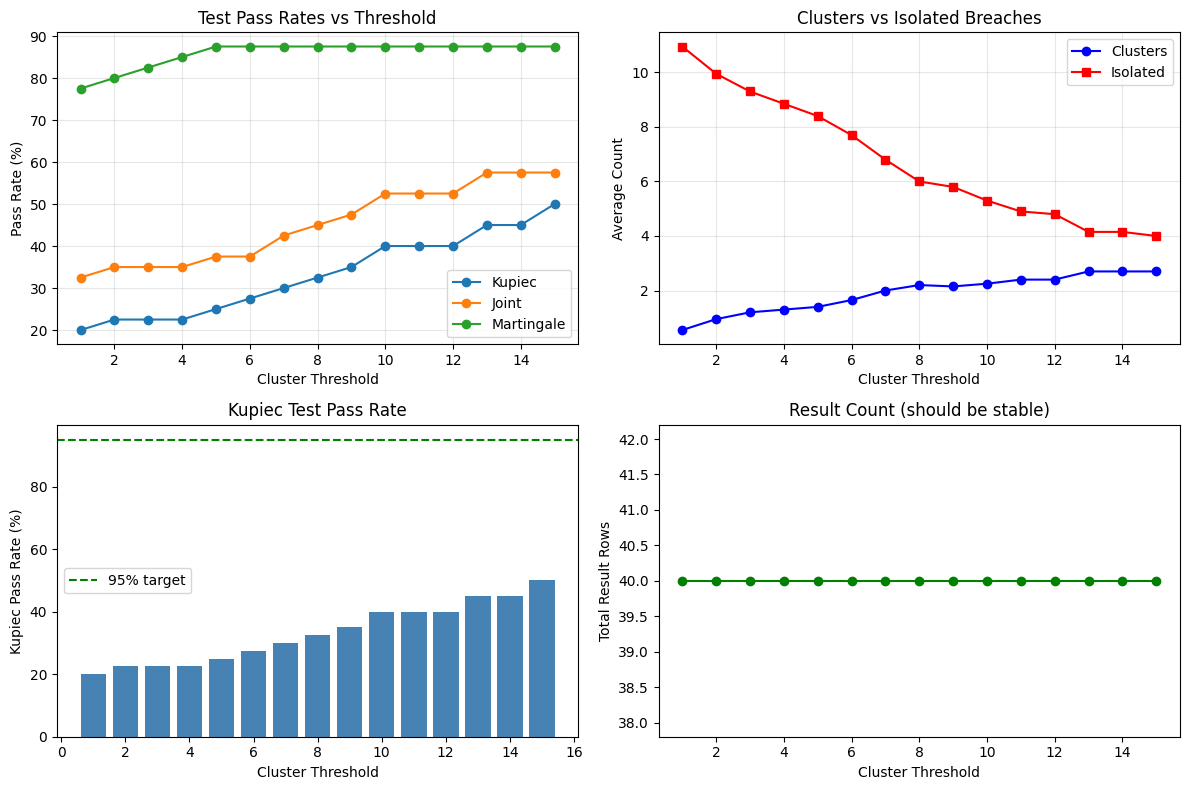

In [5]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Pass rates
    ax = axes[0, 0]
    for col in ['Pass_Rate_Kupiec', 'Pass_Rate_Joint', 'Pass_Rate_Martingale']:
        ax.plot(sensitivity_df.index, sensitivity_df[col], marker='o', label=col.replace('Pass_Rate_', ''))
    ax.set_xlabel('Cluster Threshold')
    ax.set_ylabel('Pass Rate (%)')
    ax.set_title('Test Pass Rates vs Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Cluster counts
    ax = axes[0, 1]
    ax.plot(sensitivity_df.index, sensitivity_df['Avg_Clusters'], 'b-o', label='Clusters')
    ax.plot(sensitivity_df.index, sensitivity_df['Avg_Isolated'], 'r-s', label='Isolated')
    ax.set_xlabel('Cluster Threshold')
    ax.set_ylabel('Average Count')
    ax.set_title('Clusters vs Isolated Breaches')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Kupiec detail
    ax = axes[1, 0]
    ax.bar(sensitivity_df.index, sensitivity_df['Pass_Rate_Kupiec'], color='steelblue')
    ax.axhline(y=95, color='green', linestyle='--', label='95% target')
    ax.set_xlabel('Cluster Threshold')
    ax.set_ylabel('Kupiec Pass Rate (%)')
    ax.set_title('Kupiec Test Pass Rate')
    ax.legend()

    # Total results stability
    ax = axes[1, 1]
    ax.plot(sensitivity_df.index, sensitivity_df['Total_Results'], 'g-o')
    ax.set_xlabel('Cluster Threshold')
    ax.set_ylabel('Total Result Rows')
    ax.set_title('Result Count (should be stable)')

    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install matplotlib for charts: pip install matplotlib")

## Understanding Cluster Detection

In [6]:
# Visualize how threshold affects a single fund's clusters
fund_returns = returns_dict["Fund_02"]
fund_var = var_dict["Fund_02"]
overshoots = fund_returns < -fund_var

print(f"Total breaches: {overshoots.sum()}")
print(f"Breach positions: {np.where(overshoots)[0].tolist()}")
print()

for ct in [1, 3, 5, 7, 10]:
    starts, isolated, real, adj = detect_cluster(overshoots, threshold=ct)
    n_clusters = starts.sum()
    n_isolated = isolated.sum()
    n_adj = adj.sum()
    print(f"  CT={ct:2d}: clusters={n_clusters}, isolated={n_isolated}, adj_breaches={n_adj}")

Total breaches: 26
Breach positions: [14, 17, 81, 82, 93, 101, 105, 108, 160, 163, 166, 169, 172, 181, 237, 273, 306, 321, 328, 378, 386, 426, 442, 503, 511, 582]

  CT= 1: clusters=1, isolated=24, adj_breaches=25
  CT= 3: clusters=4, isolated=15, adj_breaches=19
  CT= 5: clusters=4, isolated=14, adj_breaches=18
  CT= 7: clusters=5, isolated=12, adj_breaches=17
  CT=10: clusters=7, isolated=6, adj_breaches=13


## Choosing the Right Threshold

**Heuristic guidance:**
- CT < 3: Very aggressive clustering — almost all multi-day drawdowns become one event
- CT = 5 (default): Balanced — captures genuinely correlated breach episodes
- CT > 10: Conservative — only very tight bursts are clustered
- CT = ∞: No clustering at all (equivalent to unadjusted tests)

Look for the threshold where pass rates stabilize — that indicates the natural
cluster scale in your data.

In [7]:
# Find the "elbow" — threshold where clusters stabilize
cluster_diff = sensitivity_df['Avg_Clusters'].diff().abs()
stable_threshold = cluster_diff[cluster_diff < 0.1].index.min()
print(f"Clusters stabilize at threshold ≥ {stable_threshold}")
print(f"Recommended threshold: {max(stable_threshold - 1, 3) if pd.notna(stable_threshold) else 5}")

Clusters stabilize at threshold ≥ 5
Recommended threshold: 4
